<a href="https://colab.research.google.com/github/susanburrell-ut/ML-Guided-Thyroid-Classification/blob/main/thyroid_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thyroid Ultrasound: CNN Classification (DenseNet121 / ResNet50)

This notebook trains a pretrained CNN on the same TN5000 dataset used in `thyroid_classification.ipynb`.
It reuses the same `parse_xml` and `load_split` functions — no data is re-processed differently.

**Key differences from the logistic regression notebook:**
- Raw ROI crops are fed directly to the CNN (no hand-crafted GLCM/intensity features)
- Images are resized to 224×224 and normalized with ImageNet statistics
- The final classifier layer is replaced with a 2-class output and fine-tuned

**Dataset structure (same as before):**
```
TN5000_forReview/
  JPEGImages/        ← .jpg ultrasound images
  Annotations/       ← .xml Pascal VOC annotation files
  ImageSets/Main/
    train.txt
    val.txt
    test.txt
```

## 1. Imports & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR = Path("/content/drive/MyDrive/TN5000/TN5000_forReview")


Mounted at /content/drive


In [1]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import torchvision.models as models
import torchvision.transforms as transforms

# Evaluation (same as logistic regression notebook)
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")

All imports successful.
PyTorch version : 2.10.0+cu128
GPU available   : True


## 2. Configuration — Set Your Paths Here

These are identical to the logistic regression notebook. Only change `ARCH` to switch between models.

In [3]:
# ── Dataset paths (same as thyroid_classification.ipynb) ─────────────────────
DATA_DIR = Path("/content/drive/MyDrive/TN5000_forReview/TN5000")
IMAGE_DIR      = DATA_DIR / "JPEGImages"
ANNOTATION_DIR = DATA_DIR / "Annotations"
TRAIN_TXT      = DATA_DIR / "ImageSets" / "Main" / "train.txt"
VAL_TXT        = DATA_DIR / "ImageSets" / "Main" / "val.txt"
TEST_TXT       = DATA_DIR / "ImageSets" / "Main" / "test.txt"
CLASS_MAP      = {0: "benign", 1: "malignant"}

# ── CNN settings — change these to experiment ────────────────────────────────
ARCH       = "densenet121"   # options: "densenet121" or "resnet50"
EPOCHS     = 20
BATCH_SIZE = 32
LR         = 1e-4

# Verify paths exist
print(f"Images     : {IMAGE_DIR}  → exists: {IMAGE_DIR.exists()}")
print(f"Annotations: {ANNOTATION_DIR}  → exists: {ANNOTATION_DIR.exists()}")
print(f"Train split: {TRAIN_TXT.exists()}")

Images     : /content/drive/MyDrive/TN5000_forReview/TN5000/JPEGImages  → exists: True
Annotations: /content/drive/MyDrive/TN5000_forReview/TN5000/Annotations  → exists: True
Train split: True


## 3. Parse Annotations & Load Splits

These two functions are copied directly from `thyroid_classification.ipynb` — no changes.
They read the Pascal VOC XML files and return a DataFrame with one row per bounding box.

Scanning available files...


Loading train: 100%|██████████| 3500/3500 [00:46<00:00, 75.70it/s] 


Scanning available files...


Loading val: 100%|██████████| 500/500 [00:01<00:00, 382.79it/s]


Scanning available files...


Loading test: 100%|██████████| 1000/1000 [00:02<00:00, 416.30it/s]


Train samples : 3500
Val samples   : 500
Test samples  : 1000
   img_id                                           img_path  label  xmin  \
0  001469  /content/drive/MyDrive/TN5000_forReview/TN5000...      1   225   
1  001392  /content/drive/MyDrive/TN5000_forReview/TN5000...      1   549   
2  004755  /content/drive/MyDrive/TN5000_forReview/TN5000...      1   221   
3  003890  /content/drive/MyDrive/TN5000_forReview/TN5000...      1   273   
4  000557  /content/drive/MyDrive/TN5000_forReview/TN5000...      0   370   

   ymin  xmax  ymax  
0   114   397   265  
1   129   674   259  
2   129   267   211  
3   102   398   175  
4   113   448   171  
Split        Benign  Malignant  Ratio (M:B)
Train          1032       2468        2.39x
Val             125        375        3.00x
Test            269        731        2.72x


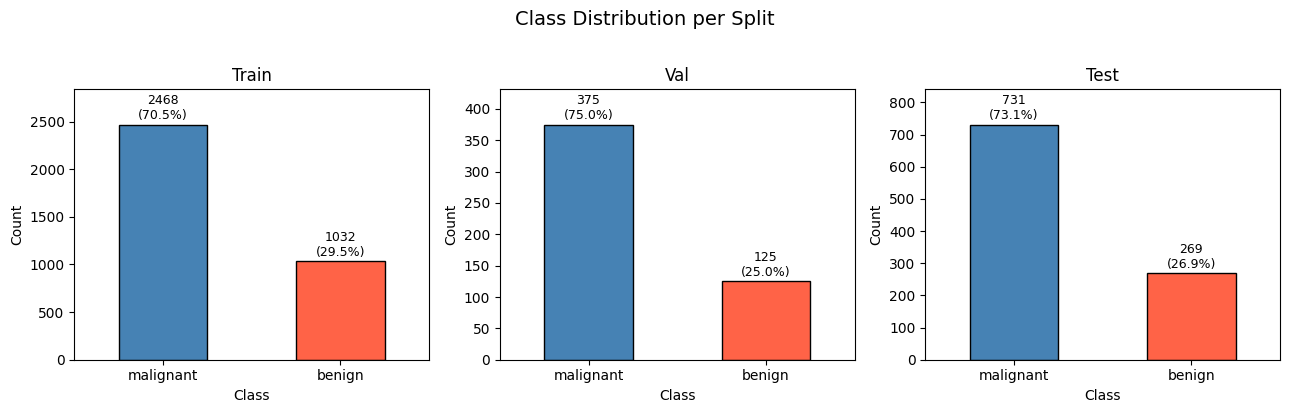

In [4]:
!pip install tqdm -q
from tqdm import tqdm

def parse_xml(xml_path):
    """Parse a Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall("object"):
        label = int(obj.findtext("name"))
        bb = obj.find("bndbox")
        objects.append({
            "label": label,
            "xmin" : int(bb.findtext("xmin")),
            "ymin" : int(bb.findtext("ymin")),
            "xmax" : int(bb.findtext("xmax")),
            "ymax" : int(bb.findtext("ymax")),
        })
    return {"filename": root.findtext("filename"), "objects": objects}


def load_split(txt_file, image_dir, annotation_dir):
    """Load image IDs from a split .txt file and return a DataFrame of crops."""
    ids = Path(txt_file).read_text().strip().splitlines()

    # Build a set of available files once — much faster than checking one by one
    print("Scanning available files...")
    available_imgs = {f.stem for f in image_dir.glob("*.jpg")}
    available_xmls = {f.stem for f in annotation_dir.glob("*.xml")}

    records = []
    for img_id in tqdm(ids, desc=f"Loading {Path(txt_file).stem}"):
        img_id = img_id.strip()
        if img_id not in available_imgs or img_id not in available_xmls:
            continue
        xml_path = annotation_dir / f"{img_id}.xml"
        img_path = image_dir      / f"{img_id}.jpg"
        try:
            ann = parse_xml(xml_path)
        except Exception as e:
            print(f"Error parsing {xml_path}: {e}")
            continue
        for obj in ann["objects"]:
            records.append({
                "img_id"  : img_id,
                "img_path": str(img_path),
                "label"   : obj["label"],
                "xmin"    : obj["xmin"],
                "ymin"    : obj["ymin"],
                "xmax"    : obj["xmax"],
                "ymax"    : obj["ymax"],
            })
    return pd.DataFrame(records)


df_train = load_split(TRAIN_TXT, IMAGE_DIR, ANNOTATION_DIR)
df_val   = load_split(VAL_TXT,   IMAGE_DIR, ANNOTATION_DIR)
df_test  = load_split(TEST_TXT,  IMAGE_DIR, ANNOTATION_DIR)

print(f"Train samples : {len(df_train)}")
print(f"Val samples   : {len(df_val)}")
print(f"Test samples  : {len(df_test)}")
print(df_train.head())


def class_imbalance_report(df_train, df_val, df_test, class_map):
    print("=" * 45)
    print(f"{'Split':<10} {'Benign':>8} {'Malignant':>10} {'Ratio (M:B)':>12}")
    print("=" * 45)

    for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
        n_benign    = (df["label"] == 0).sum()
        n_malignant = (df["label"] == 1).sum()
        ratio       = n_malignant / n_benign if n_benign > 0 else float("inf")
        print(f"{name:<10} {n_benign:>8} {n_malignant:>10} {ratio:>11.2f}x")

    print("=" * 45)

    # Combined bar chart
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (df, title) in zip(axes, [(df_train, "Train"), (df_val, "Val"), (df_test, "Test")]):
        counts = df["label"].map(class_map).value_counts()
        bars   = counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="k")
        ax.set_title(title)
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)

        # Add count + percentage labels on each bar
        total = counts.sum()
        for bar in bars.patches:
            height = bar.get_height()
            ax.annotate(f"{int(height)}\n({height/total*100:.1f}%)",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", fontsize=9)

        # Add 15% headroom above the tallest bar so labels aren't clipped
        ax.set_ylim(0, counts.max() * 1.15)

    plt.suptitle("Class Distribution per Split", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

class_imbalance_report(df_train, df_val, df_test, CLASS_MAP)

## 4. PyTorch Dataset & Transforms

The `ThyroidROIDataset` class replaces `build_feature_matrix` from the logistic regression notebook.
Instead of computing GLCM/intensity features, it:
1. Opens the full image
2. Crops the bounding box ROI (same region used before)
3. Resizes to 224×224 (required by pretrained ImageNet models)
4. Normalizes with ImageNet mean/std so pretrained weights are valid

Training transforms include random flips and brightness jitter for data augmentation.
Validation/test transforms are deterministic (no random augmentation).

In [5]:
# ImageNet normalization constants — required for pretrained DenseNet/ResNet weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class ThyroidROIDataset(Dataset):
    """
    Reads bounding box crops from the same DataFrame produced by load_split().
    Each item is a (tensor, label) pair — same label encoding as the logistic
    regression notebook: 0 = benign, 1 = malignant.
    """
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        roi = img.crop((row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if self.transform:
            roi = self.transform(roi)
        return roi, int(row["label"])


# Build datasets
train_ds = ThyroidROIDataset(df_train, transform=train_transform)
val_ds   = ThyroidROIDataset(df_val,   transform=val_transform)
test_ds  = ThyroidROIDataset(df_test,  transform=val_transform)

# Build DataLoaders (num_workers=0 is safest on Windows)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Sanity check — peek at one batch
imgs, labels = next(iter(train_loader))
print(f"Batch shape   : {imgs.shape}   (batch, channels, height, width)")
print(f"Label sample  : {labels[:8].tolist()}")

Train batches : 110
Val batches   : 16
Test batches  : 32
Batch shape   : torch.Size([32, 3, 224, 224])   (batch, channels, height, width)
Label sample  : [1, 1, 1, 1, 1, 1, 1, 1]


## 5. Build the CNN Model

We load a pretrained DenseNet121 or ResNet50 (weights trained on ImageNet) and replace
the final classification layer with a new 2-class output. Everything else stays the same.

Change `ARCH` in Cell 2 to switch between models — no other code needs to change.

In [6]:
def build_model(arch="densenet121"):
    """
    Load a pretrained model and replace its classifier head with a 2-class output.
    - DenseNet121: replaces model.classifier (single Linear layer)
    - ResNet50   : replaces model.fc          (single Linear layer)
    """
    if arch == "densenet121":
        model = models.densenet121(weights="IMAGENET1K_V1")
        in_features = model.classifier.in_features   # 1024
        model.classifier = nn.Linear(in_features, 2)

    elif arch == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V2")
        in_features = model.fc.in_features           # 2048
        model.fc = nn.Linear(in_features, 2)

    else:
        raise ValueError(f"Unknown arch '{arch}'. Choose 'densenet121' or 'resnet50'.")

    return model


model = build_model(ARCH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

print(f"Model    : {ARCH}")
print(f"Device   : {device}")

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

Model    : densenet121
Device   : cuda
Parameters: 6,955,906


## 6. Train the Model

The training loop runs for `EPOCHS` epochs. After each epoch it prints validation
accuracy and AUC so you can watch for overfitting.

- **Loss**: CrossEntropyLoss (no class weighting for now — can be added later)
- **Optimizer**: Adam with weight decay
- **Scheduler**: learning rate drops by 10× at epoch 7 and 14

In [7]:
# Calculate weights inversely proportional to class frequency in training set
n_benign    = (df_train["label"] == 0).sum()
n_malignant = (df_train["label"] == 1).sum()
n_total     = n_benign + n_malignant

weight_benign    = n_total / (2 * n_benign)
weight_malignant = n_total / (2 * n_malignant)

class_weights = torch.tensor([weight_benign, weight_malignant], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"Class weights — benign: {weight_benign:.3f}, malignant: {weight_malignant:.3f}")

# unweighted
# criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

train_losses = []
val_losses   = []
val_aucs     = []

for epoch in range(EPOCHS):

    # ── Training pass ────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation pass ───────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)          # <-- val loss added
            val_loss += loss.item()
            probs   = torch.softmax(outputs, dim=1)[:, 1]
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = accuracy_score(all_labels, all_preds)
    val_auc = roc_auc_score(all_labels, all_probs)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS}  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Val Loss: {avg_val_loss:.4f}  "
          f"Val Acc: {val_acc:.3f}  "
          f"Val AUC: {val_auc:.3f}")

print("\nTraining complete.")

Epoch 01/20  Train Loss: 0.4580  Val Loss: 0.3369  Val Acc: 0.876  Val AUC: 0.936
Epoch 02/20  Train Loss: 0.3580  Val Loss: 0.2293  Val Acc: 0.892  Val AUC: 0.971
Epoch 03/20  Train Loss: 0.3153  Val Loss: 0.2950  Val Acc: 0.882  Val AUC: 0.947
Epoch 04/20  Train Loss: 0.2866  Val Loss: 0.3225  Val Acc: 0.838  Val AUC: 0.938
Epoch 05/20  Train Loss: 0.2770  Val Loss: 0.2827  Val Acc: 0.884  Val AUC: 0.949
Epoch 06/20  Train Loss: 0.2462  Val Loss: 0.2575  Val Acc: 0.910  Val AUC: 0.961
Epoch 07/20  Train Loss: 0.2130  Val Loss: 0.2662  Val Acc: 0.888  Val AUC: 0.958
Epoch 08/20  Train Loss: 0.1711  Val Loss: 0.2451  Val Acc: 0.900  Val AUC: 0.962
Epoch 09/20  Train Loss: 0.1512  Val Loss: 0.2374  Val Acc: 0.886  Val AUC: 0.965
Epoch 10/20  Train Loss: 0.1347  Val Loss: 0.2333  Val Acc: 0.902  Val AUC: 0.966
Epoch 11/20  Train Loss: 0.1262  Val Loss: 0.2442  Val Acc: 0.904  Val AUC: 0.963
Epoch 12/20  Train Loss: 0.1182  Val Loss: 0.2550  Val Acc: 0.902  Val AUC: 0.960
Epoch 13/20  Tra

## 7. Plot Training Curves

A quick check for overfitting — if training loss keeps dropping but val AUC plateaus or falls,
the model is memorising the training set.

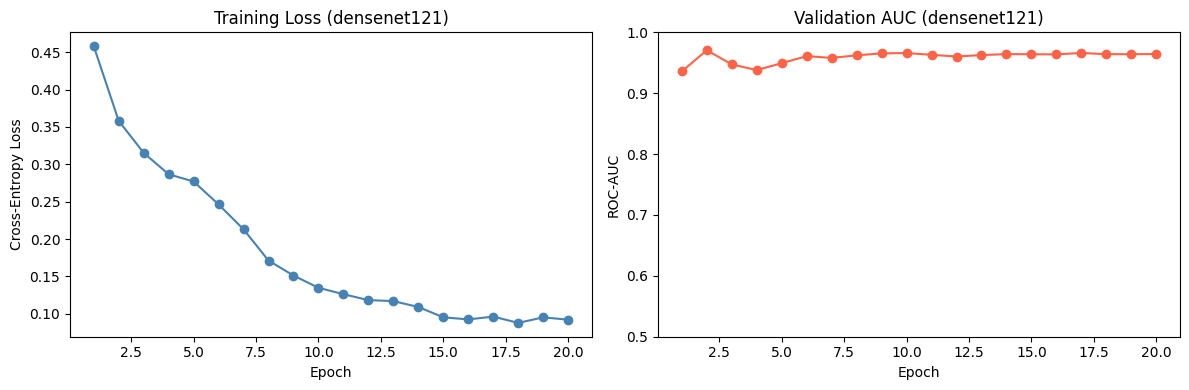

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, marker="o", color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title(f"Training Loss ({ARCH})")

axes[1].plot(range(1, EPOCHS+1), val_aucs, marker="o", color="tomato")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title(f"Validation AUC ({ARCH})")
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

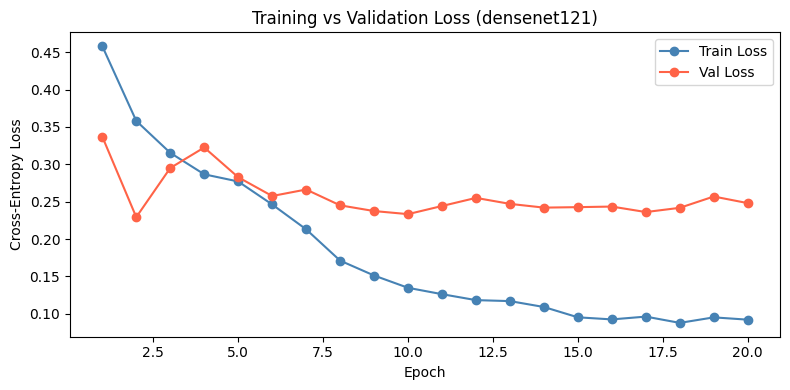

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker="o", color="steelblue", label="Train Loss")
plt.plot(range(1, EPOCHS+1), val_losses,   marker="o", color="tomato",    label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Training vs Validation Loss ({ARCH})")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Evaluate on Validation Set

Same metrics and plot layout as Sections 7–8 of `thyroid_classification.ipynb`:
confusion matrix + ROC curve.

── Validation Results (densenet121) ──
Accuracy : 0.916
ROC-AUC  : 0.964

              precision    recall  f1-score   support

      benign       0.82      0.86      0.84       125
   malignant       0.95      0.94      0.94       375

    accuracy                           0.92       500
   macro avg       0.88      0.90      0.89       500
weighted avg       0.92      0.92      0.92       500



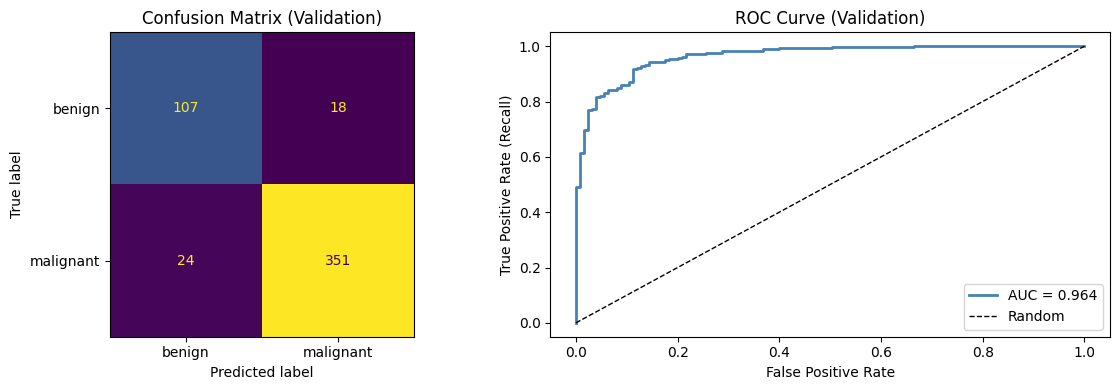

In [10]:
def evaluate_cnn(model, data_loader, split_name="Validation"):
    """Evaluate a trained CNN and display confusion matrix + ROC curve."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs    = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)[:, 1]  # P(malignant)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    # ── Print metrics ─────────────────────────────────────────────────────────
    print(f"── {split_name} Results ({ARCH}) ──")
    print(f"Accuracy : {accuracy_score(all_labels, all_preds):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(all_labels, all_probs):.3f}")
    print()
    print(classification_report(all_labels, all_preds,
                                 target_names=["benign", "malignant"]))

    # ── Confusion matrix + ROC curve ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_predictions(
        all_labels, all_preds,
        display_labels=["benign", "malignant"],
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f"Confusion Matrix ({split_name})")

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc = roc_auc_score(all_labels, all_probs)
    axes[1].plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate (Recall)")
    axes[1].set_title(f"ROC Curve ({split_name})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


evaluate_cnn(model, val_loader, split_name="Validation")

## 9. Final Evaluation on Test Set

Run this **once only** after you are done tuning. Matches the structure of Section 9
in `thyroid_classification.ipynb` so results are directly comparable.

── Test Results (densenet121) ──
Accuracy : 0.863
ROC-AUC  : 0.925

              precision    recall  f1-score   support

      benign       0.73      0.78      0.75       269
   malignant       0.92      0.89      0.90       731

    accuracy                           0.86      1000
   macro avg       0.82      0.84      0.83      1000
weighted avg       0.87      0.86      0.86      1000



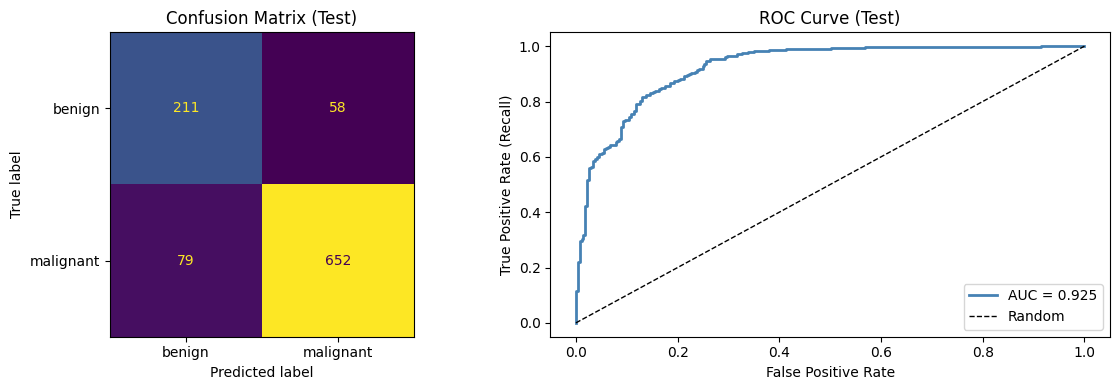

In [11]:
evaluate_cnn(model, test_loader, split_name="Test")